# 1. Business Problem

Hospitals generate large volumes of inpatient data containing patient demographics, admission details, diagnoses, and treatment information. Predicting total hospital charges can help healthcare providers improve financial planning, optimize resource allocation, support billing processes, and identify patients likely to incur higher treatment costs.

# 2. Project Objective

The objective of this project is to develop a machine learning model capable of predicting hospital inpatient charges using patient demographics, admission characteristics, diagnosis information, and clinical severity. Additionally, the project aims to identify key factors influencing inpatient charges and derive actionable business insights from the model.

# 3. Business Value

Improve hospital financial planning

Estimate treatment costs

Support insurance claim processing

Identify high-cost patient groups

Enable data-driven healthcare decisions

# 4. Machine Learning Problem Statement

**Problem Type**

Regression

**Target Variable**

Total Charges

**Prediction Goal**

Estimate the expected hospital charges for an inpatient using demographic and clinical information available in the dataset.

# 5. Dataset Overview

| Attribute | Value                                |
| --------- | ------------------------------------ |
| Dataset   | SPARCS Hospital Inpatient Discharges |
| Source    | New York State Department of Health  |
| Rows      | 32033                                |
| Columns   | 34                                   |
| Target    | Total Charges                        |


# 6. Project Workflow

Phase 1  → Business Understanding

Phase 2  → Data Understanding

Phase 3  → Data Cleaning

Phase 4  → Exploratory Data Analysis (EDA)

Phase 5  → Feature Engineering

Phase 6  → Data Preprocessing

Phase 7  → Baseline Machine Learning Models

Phase 8  → Model Evaluation & Comparison

Phase 9  → Hyperparameter Tuning

Phase 10 → Model Explainability & Residual Analysis

Phase 11 → Artificial Neural Network (ANN)

Phase 12 → Business Insights & Final Conclusion

# 7. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

# 8. Load Dataset

In [2]:
med_df=pd.read_csv('/kaggle/input/datasets/sb100500/hospital-inpatient-discharges/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2009_20260723.csv')

# 9. Data Understanding

In [3]:
#Dataset Shape-how many rows and columns
med_df.shape

(32033, 34)

In [4]:
#Dataset Preview-head() or tail() or sample(5)
med_df.head()

,Health Service Area,Hospital County,Operating Certificate Number,Facility ID,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Risk of Mortality,APR Medical Surgical Description,Source of Payment 1,Source of Payment 2,Source of Payment 3,Birth Weight,Abortion Edit Indicator,Emergency Department Indicator,Total Charges,Total Costs
0,Central NY,Broome,303001,42,United Health Services Hospitals Inc. - Bingha...,50 to 69,137,M,White,Not Span/Hispanic,...,Minor,Surgical,Insurance Company,NaN,NaN,0,N,N,"$25,598.10","$13,362.19"
1,Central NY,Broome,303001,42,United Health Services Hospitals Inc. - Bingha...,50 to 69,137,M,White,Not Span/Hispanic,...,Moderate,Medical,Blue Cross,NaN,NaN,0,N,N,"$47,052.70","$20,690.05"
2,Central NY,Broome,303001,42,United Health Services Hospitals Inc. - Bingha...,50 to 69,137,M,White,Not Span/Hispanic,...,Moderate,Medical,Medicare,Medicaid,NaN,0,N,N,"$4,837.30","$4,223.20"
3,Central NY,Broome,303001,42,United Health Services Hospitals Inc. - Bingha...,50 to 69,137,M,White,Not Span/Hispanic,...,Minor,Surgical,Blue Cross,Medicare,Medicare,0,N,N,"$26,161.50","$13,838.39"
4,Central NY,Broome,303001,42,United Health Services Hospitals Inc. - Bingha...,50 to 69,137,M,White,Not Span/Hispanic,...,Minor,Surgical,Medicare,Medicare,Blue Cross,0,N,N,"$27,394.50","$15,019.50"


In [5]:
#Dataset Information
med_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32033 entries, 0 to 32032
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Health Service Area                  32033 non-null  object 
 1   Hospital County                      32033 non-null  object 
 2   Operating Certificate Number         32033 non-null  int64  
 3   Facility ID                          32033 non-null  int64  
 4   Facility Name                        32033 non-null  object 
 5   Age Group                            32033 non-null  object 
 6   Zip Code - 3 digits                  32010 non-null  object 
 7   Gender                               32033 non-null  object 
 8   Race                                 32033 non-null  object 
 9   Ethnicity                            32033 non-null  object 
 10  Length of Stay                       32033 non-null  object 
 11  Type of Admission           

In [6]:
#Statistical Summary-Numerical and Categorical
print(f'Numerical features: {med_df.describe()}')
print(f'Categorical features: {med_df.describe(include=object)}')

Numerical features:        Operating Certificate Number   Facility ID  Discharge Year  \
count                  32033.000000  32033.000000         32033.0   
mean                  336068.927606     54.496925          2009.0   
std                   128419.004981     20.703678             0.0   
min                   301001.000000     42.000000          2009.0   
25%                   301001.000000     43.000000          2009.0   
50%                   303001.000000     43.000000          2009.0   
75%                   303001.000000     58.000000          2009.0   
max                   824000.000000    128.000000          2009.0   

       CCS Diagnosis Code  CCS Procedure Code  APR DRG Code  APR MDC Code  \
count        32024.000000        32024.000000  32033.000000  32033.000000   
mean           192.777136           86.564795    398.699622      9.991946   
std            144.980340           83.303286    239.010764      5.893949   
min              1.000000            0.000000     

In [7]:
#Duplicate Records
med_df.duplicated().sum()

np.int64(45)

In [8]:
med_df.nunique().sort_values()

Health Service Area                        1
Discharge Year                             1
Abortion Edit Indicator                    1
Gender                                     2
Emergency Department Indicator             2
Hospital County                            2
Ethnicity                                  3
Operating Certificate Number               3
APR Medical Surgical Description           3
Race                                       4
Facility ID                                4
APR Risk of Mortality                      4
APR Severity of Illness Description        4
Facility Name                              4
Type of Admission                          5
Age Group                                  5
APR Severity of Illness Code               5
Source of Payment 1                        8
Source of Payment 3                        9
Source of Payment 2                        9
Patient Disposition                       15
APR MDC Code                              26
APR MDC De

In [9]:
#Missing Value Analysis
missing=pd.DataFrame({
    "Missing Values": med_df.isnull().sum(),
    "Percentage":(med_df.isnull().sum()/len(med_df))*100
})
missing.sort_values("Missing Values",ascending=False)

,Missing Values,Percentage
Source of Payment 3,24226,75.628258
Source of Payment 2,15131,47.235663
Zip Code - 3 digits,23,0.071801
CCS Procedure Description,9,0.028096
CCS Diagnosis Code,9,0.028096
CCS Diagnosis Description,9,0.028096
CCS Procedure Code,9,0.028096
APR Risk of Mortality,2,0.006244
APR Severity of Illness Description,2,0.006244
Health Service Area,0,0.000000


# 10. Data Cleaning

In [10]:
#Always create a copy of the dataset
med_df1=med_df.copy()

In [11]:
#drop duplicate values
med_df1.drop_duplicates(inplace=True)

In [12]:
#check whether the duplicates are dropped or not
med_df1.duplicated().sum()

np.int64(0)

In [13]:
#Drop columns with excessive missing values
med_df1.drop(columns=['Source of Payment 2','Source of Payment 3','CCS Diagnosis Code','CCS Procedure Code','Operating Certificate Number',
                     'Facility ID','APR DRG Code','APR MDC Code','APR MDC Description','APR Severity of Illness Code','Birth Weight','Abortion Edit Indicator','Discharge Year','Health Service Area'],inplace=True)

In [14]:
#Fill the categorical missing data
med_df1['CCS Procedure Description']=(med_df1['CCS Procedure Description'].fillna('Unknown'))
med_df1['CCS Diagnosis Description']=(med_df1['CCS Diagnosis Description'].fillna('Unknown'))
med_df1['APR Severity of Illness Description']=(med_df1['APR Severity of Illness Description'].fillna('Unknown'))
med_df1['APR Risk of Mortality']=(med_df1['APR Risk of Mortality'].fillna('Unknown'))
med_df1['Zip Code - 3 digits']=(med_df1['Zip Code - 3 digits'].replace('OOS','Out of State').fillna('Unknown'))

In [15]:
#check the null count
med_df1.isnull().sum()

Hospital County                        0
Facility Name                          0
Age Group                              0
Zip Code - 3 digits                    0
Gender                                 0
Race                                   0
Ethnicity                              0
Length of Stay                         0
Type of Admission                      0
Patient Disposition                    0
CCS Diagnosis Description              0
CCS Procedure Description              0
APR DRG Description                    0
APR Severity of Illness Description    0
APR Risk of Mortality                  0
APR Medical Surgical Description       0
Source of Payment 1                    0
Emergency Department Indicator         0
Total Charges                          0
Total Costs                            0
dtype: int64

In [16]:
#check the object type and proceed the data cleaning
med_df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31988 entries, 0 to 32032
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Hospital County                      31988 non-null  object
 1   Facility Name                        31988 non-null  object
 2   Age Group                            31988 non-null  object
 3   Zip Code - 3 digits                  31988 non-null  object
 4   Gender                               31988 non-null  object
 5   Race                                 31988 non-null  object
 6   Ethnicity                            31988 non-null  object
 7   Length of Stay                       31988 non-null  object
 8   Type of Admission                    31988 non-null  object
 9   Patient Disposition                  31988 non-null  object
 10  CCS Diagnosis Description            31988 non-null  object
 11  CCS Procedure Description            31988 non

In [17]:
#The Length of Stay column is stored as an object because it contains a special category ("120 +") representing stays of 120 days or more. 
#Therefore, no type conversion was performed during data cleaning.
#we will change it during feature engineering
med_df1['Length of Stay'].unique()


array(['2', '32', '5', '3', '4', '13', '1', '8', '18', '10', '21', '9',
       '12', '6', '7', '16', '11', '14', '64', '20', '29', '15', '43',
       '24', '28', '23', '33', '44', '25', '26', '17', '19', '36', '46',
       '35', '31', '42', '22', '34', '104', '41', '27', '72', '67', '39',
       '57', '51', '116', '37', '45', '30', '60', '40', '79', '55',
       '120 +', '68', '53', '49', '38', '87', '47', '63', '78', '81',
       '50', '70', '103', '48', '90', '82', '101', '84', '88', '54', '59',
       '61', '56', '65', '95', '77', '74', '75', '96', '66', '52', '62',
       '117', '69'], dtype=object)

In [18]:
#Observation:The Age Group feature contains five well-defined categorical age ranges with no missing or inconsistent values. 
#No cleaning was required.
#Action:#The feature will be one-hot encoded during the data preprocessing stage before model training
med_df1['Age Group'].unique()

array(['50 to 69', '18 to 29', '0 to 17', '70 or Older', '30 to 49'],
      dtype=object)

In [19]:
#The Gender feature contains two standardized categories (M and F) with no missing values or inconsistencies
#No data cleaning was required. The feature will be binary encoded during the preprocessing stage
med_df1['Gender'].unique()

array(['M', 'F'], dtype=object)

In [20]:
#No cleaning was required. The feature will be one-hot encoded during the preprocessing stage
med_df1['Race'].unique()

array(['White', 'Black/African American', 'Unknown', 'Other Race'],
      dtype=object)

In [21]:
#No data cleaning was required. The feature will be one-hot encoded during the preprocessing stage.
med_df1['Ethnicity'].unique()

array(['Not Span/Hispanic', 'Unknown', 'Spanish/Hispanic'], dtype=object)

In [22]:
#No data cleaning was required. The feature will be one-hot encoded during the preprocessing stage.
med_df1['Type of Admission'].unique()

array(['Elective', 'Emergency', 'Urgent', 'Newborn', 'Not Available'],
      dtype=object)

In [23]:
#Since there is no natural ordering, this is the appropriate encoding strategy.
med_df1['Patient Disposition'].unique()

array(['Home w/ Home Health Services', 'Home or Self Care',
       'Short-term Hospital', 'Skilled Nursing Home',
       "Cancer Center or Children's Hospital",
       'Psychiatric Hospital or Unit of Hosp', 'Expired',
       'Federal Health Care Facility', 'Hospice - Home',
       'Left Against Medical Advice', 'Inpatient Rehabilitation Facility',
       'Hosp Basd Medicare Approved Swing Bed',
       'Medicare Cert Long Term Care Hospital',
       'Hospice - Medical Facility',
       'Facility w/ Custodial/Supportive Care'], dtype=object)

In [24]:
#No data cleaning was required. The feature will be binary encoded during the preprocessing stage.
med_df1['Emergency Department Indicator'].unique()

array(['N', 'Y'], dtype=object)

In [25]:
#This is a nominal categorical feature, so one-hot encoding is the appropriate choice.
med_df1['Source of Payment 1'].unique()

array(['Insurance Company', 'Blue Cross', 'Medicare',
       'Workers Compensation', 'Medicaid', 'Other Federal Program',
       'Self-Pay', 'CHAMPUS'], dtype=object)

In [26]:
#No data cleaning was required. During preprocessing, the feature will be ordinal encoded to preserve the natural ordering of illness severity.
med_df1['APR Severity of Illness Description'].unique()

array(['Minor', 'Major', 'Moderate', 'Extreme', 'Unknown'], dtype=object)

In [27]:
#No data cleaning was required. During preprocessing, the feature will be ordinal encoded to preserve the natural ordering of mortality risk.
med_df1['APR Risk of Mortality'].unique()

array(['Minor', 'Moderate', 'Major', 'Extreme', 'Unknown'], dtype=object)

In [28]:
#No data cleaning was required. During preprocessing, the feature will be one-hot encoded because it is a nominal categorical variable.
med_df1['APR Medical Surgical Description'].unique()

array(['Surgical', 'Medical', 'Not Applicable'], dtype=object)

In [29]:
#To reduce dimensionality while preserving the most informative categories, the top 50 most frequent DRG descriptions will be retained. 
#All remaining categories will be grouped into a single "Other" category. 
#The resulting feature will then be one-hot encoded during preprocessing.

top_50 = med_df1["APR DRG Description"].value_counts().nlargest(50).index

med_df1["APR DRG Description"] = med_df1["APR DRG Description"].apply(
    lambda x: x if x in top_50 else "Other"
)

In [30]:
#One-Hot Encode the reduced categories.
top_50_diag=med_df1['CCS Diagnosis Description'].value_counts().nlargest(50).index
med_df1['CCS Diagnosis Description']=med_df1['CCS Diagnosis Description'].apply(
    lambda x: x if x in top_50_diag else 'other'
)

In [31]:
#The CCS Procedure Description feature contains 198 unique procedure categories, making it a high-cardinality categorical feature.
#To reduce dimensionality while preserving the most informative procedures, the top 50 most frequent procedure descriptions will be retained, 
#and all remaining categories will be grouped into an Other category before applying one-hot encoding
top_50_proc=med_df1['CCS Procedure Description'].value_counts().nlargest(50).index
med_df1['CCS Procedure Description']=med_df1['CCS Procedure Description'].apply(
    lambda x: x if x in top_50_proc else 'other'
)

In [32]:
#The Hospital County feature contains two standardized categories (Broome and Chenango) with no missing values or inconsistencies.
#No data cleaning was required. During preprocessing, the feature will be binary encoded because it contains only two categories.
med_df1['Hospital County'].unique()


array(['Broome', 'Chenango'], dtype=object)

In [33]:
#No further cleaning was required. 
#During preprocessing, the feature will be one-hot encoded because ZIP regions are nominal categories without a natural order.
med_df1['Zip Code - 3 digits'].nunique()

45

In [34]:
#The feature was retained because the number of categories is small and hospital-specific characteristics may influence healthcare charges. 
#During preprocessing, it will be one-hot encoded. A future experiment may compare model performance with and without this feature to evaluate its contribution.
med_df1['Facility Name'].nunique()

4

In [35]:
#converting string to float and removing '$',',' characters
med_df1['Total Charges']=(med_df1['Total Charges'].str.replace("$","",regex=False)
.str.replace(",","",regex=False).astype(float))


In [36]:
#converting string to float and removing '$',',' characters
med_df1['Total Costs']=(med_df1['Total Costs'].str.replace("$","",regex=False)
.str.replace(",","",regex=False).astype(float))


# 11. Exploratory Data Analysis-EDA

**11.1. Target Variable Analysis**

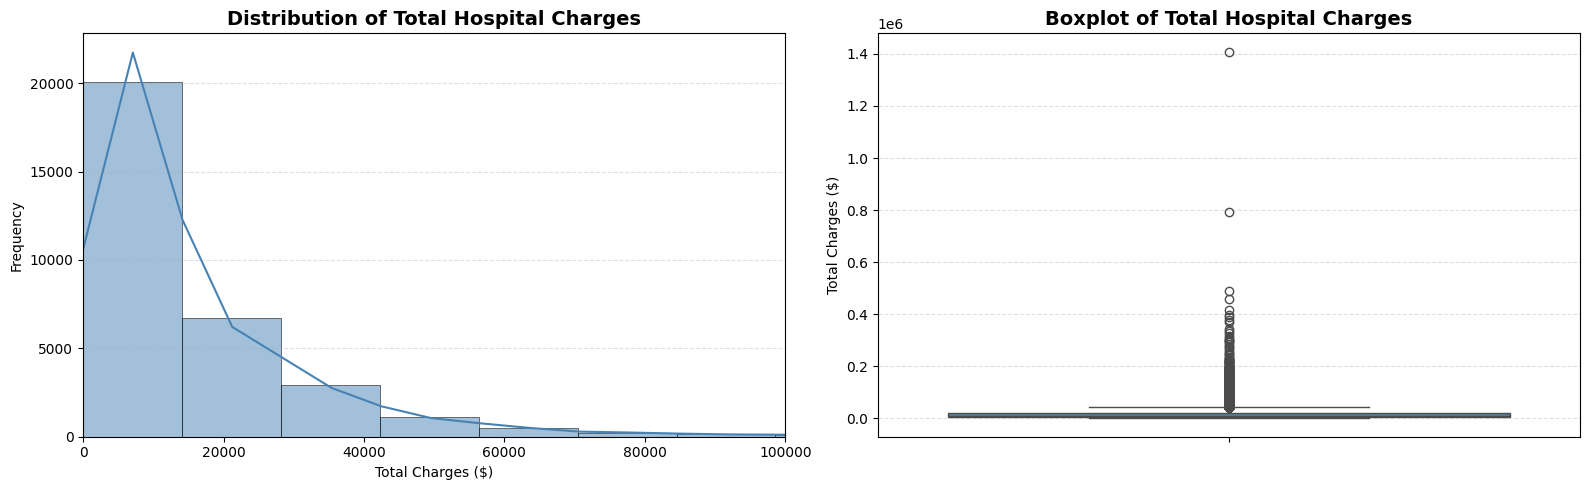

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -------------------------------
# Figure 1A: Histogram + KDE
# -------------------------------
sns.histplot(
    data=med_df1,
    x="Total Charges",
    bins=100,
    kde=True,
    color="steelblue",
    ax=axes[0]
)

axes[0].set_xlim(0, 100000)
axes[0].set_title("Distribution of Total Hospital Charges", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Total Charges ($)")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# -------------------------------
# Figure 1B: Boxplot
# -------------------------------
sns.boxplot(
    y=med_df1["Total Charges"],
    color="steelblue",
    ax=axes[1]
)

axes[1].set_title("Boxplot of Total Hospital Charges", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Total Charges ($)")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**11.2. Age Group vs. Total Charges**

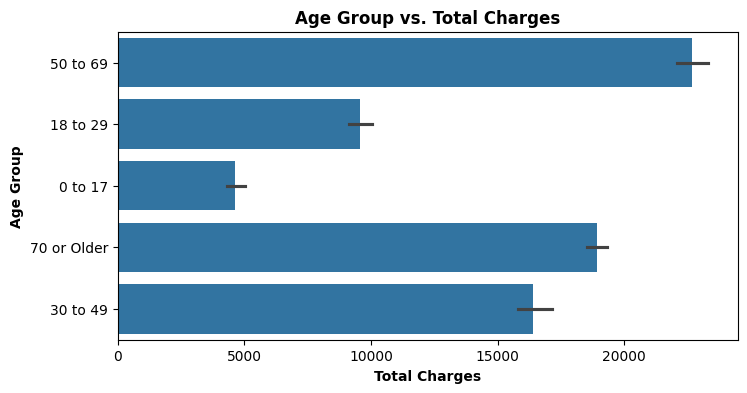

In [38]:
plt.figure(figsize=(8,4))
sns.barplot(data=med_df1,x='Total Charges',y='Age Group')
plt.title('Age Group vs. Total Charges',fontweight="bold")
plt.xlabel('Total Charges',fontweight="bold")
plt.ylabel('Age Group',fontweight="bold")
plt.show()

**11.3. Type Of Admission vs. Total Charges**

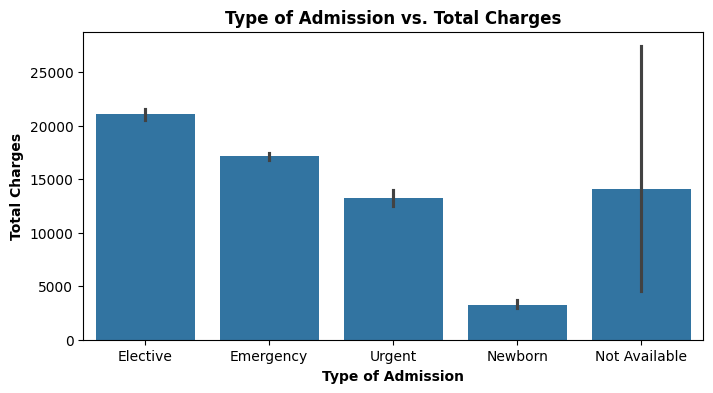

In [39]:
plt.figure(figsize=(8,4))
sns.barplot(data=med_df1,x='Type of Admission',y='Total Charges')
plt.title('Type of Admission vs. Total Charges',fontweight="bold")
plt.xlabel('Type of Admission',fontweight="bold")
plt.ylabel('Total Charges',fontweight="bold")
plt.show()

**11.4. APR Severity of Illness Description  vs. Total Charges**

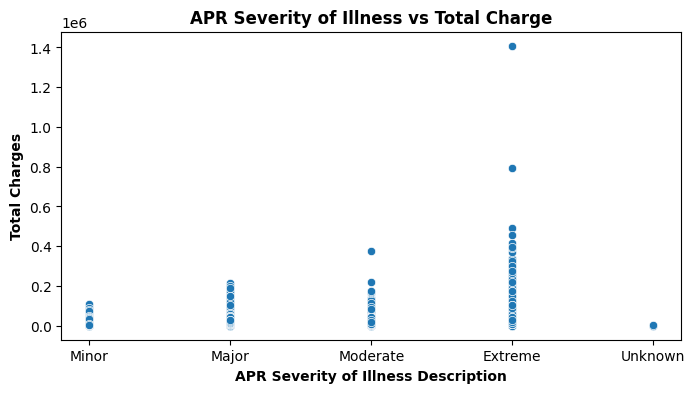

In [40]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=med_df1,x='APR Severity of Illness Description',y='Total Charges')
plt.title('APR Severity of Illness vs Total Charge',fontweight="bold")
plt.xlabel('APR Severity of Illness Description',fontweight="bold")
plt.ylabel('Total Charges',fontweight="bold")
plt.show()

**11.5. Source of Payment vs. Total Charges**

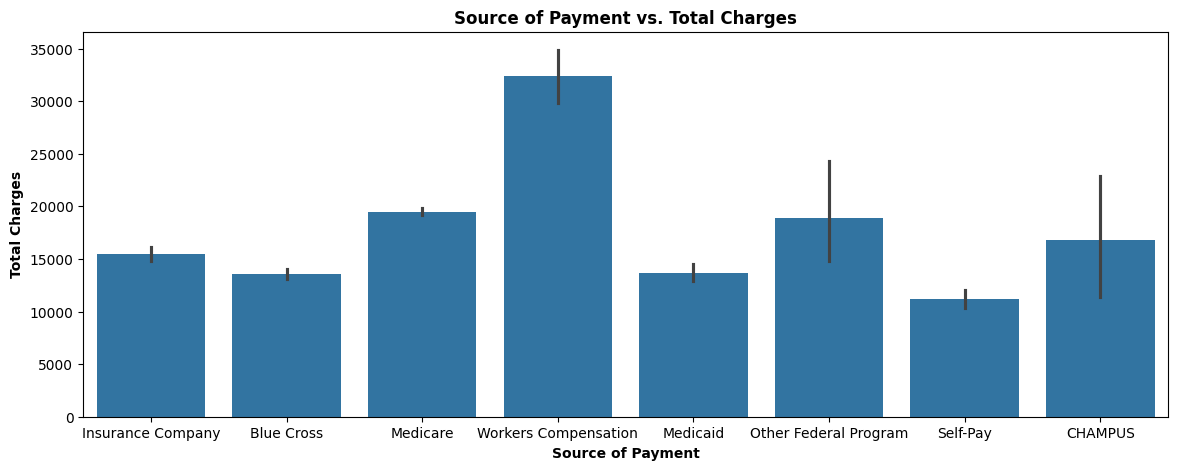

In [41]:
plt.figure(figsize=(14,5))
sns.barplot(data=med_df1,x='Source of Payment 1',y='Total Charges')
plt.title('Source of Payment vs. Total Charges',fontweight='bold')
plt.xlabel('Source of Payment',fontweight='bold')
plt.ylabel('Total Charges',fontweight='bold')
plt.show()

**11.6. Top 10 APR DRG Description**

/tmp/ipykernel_16/3324947901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


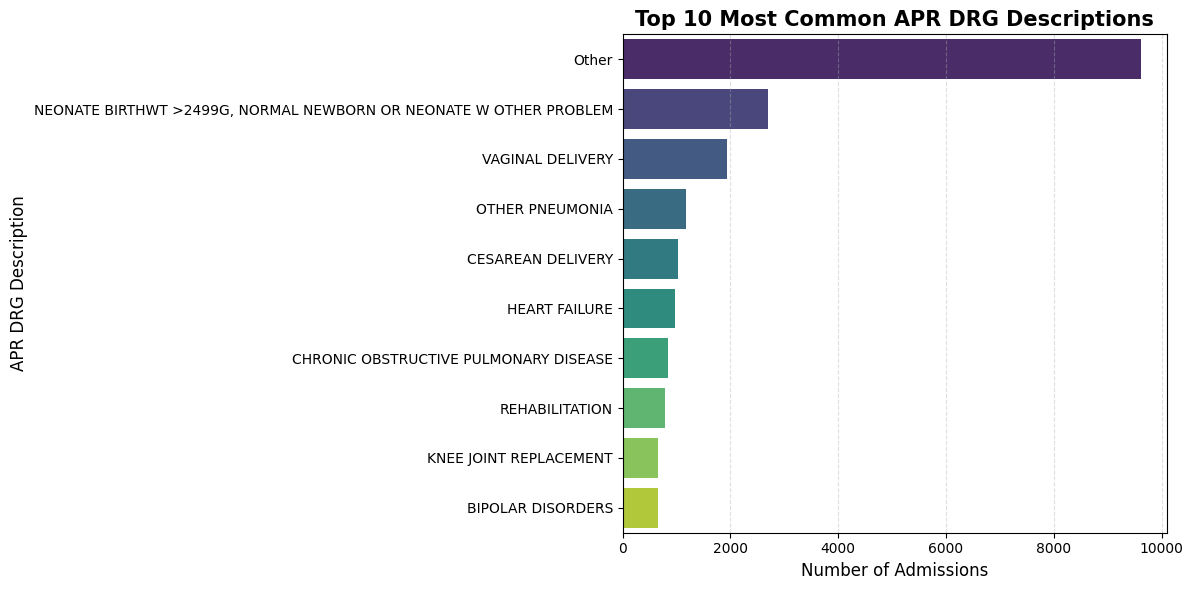

In [42]:
top10_drg = med_df1["APR DRG Description"].value_counts().nlargest(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10_drg.values,
    y=top10_drg.index,
    palette="viridis"
)

plt.title("Top 10 Most Common APR DRG Descriptions",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Number of Admissions", fontsize=12)
plt.ylabel("APR DRG Description", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**11.7. Top 10 CCS Diagnosis Description**

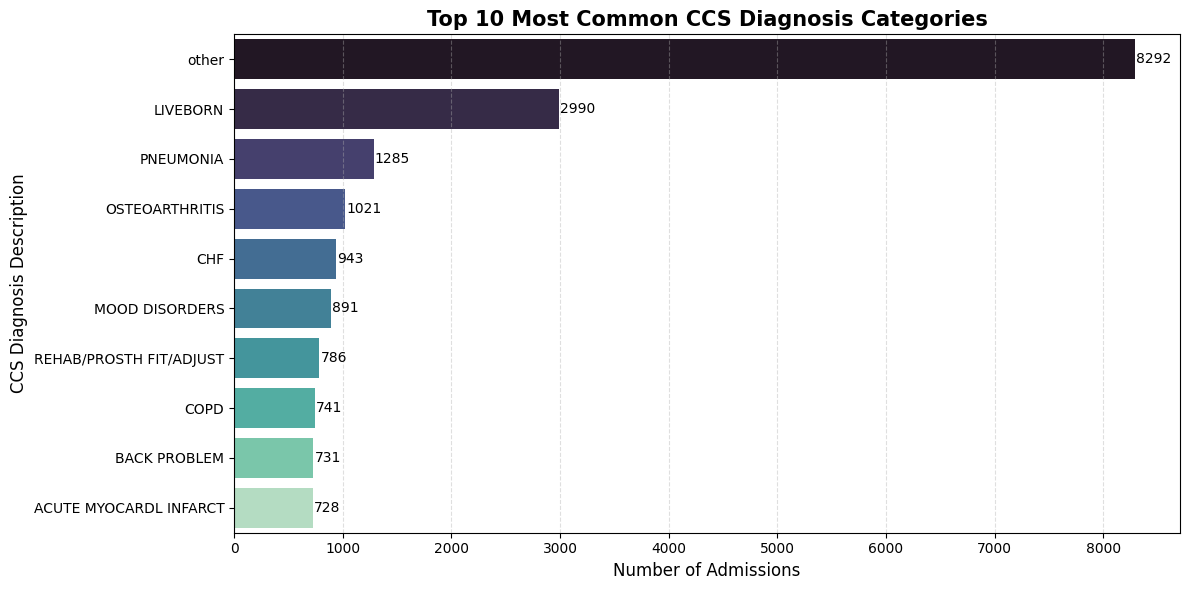

In [43]:
top10_diag = med_df1["CCS Diagnosis Description"].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top10_diag.values,
    y=top10_diag.index,
    hue=top10_diag.index,
    palette="mako",
    legend=False
)

# Add value labels
for i, value in enumerate(top10_diag.values):
    ax.text(value + 10, i, str(value), va="center", fontsize=10)

plt.title("Top 10 Most Common CCS Diagnosis Categories",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Number of Admissions", fontsize=12)
plt.ylabel("CCS Diagnosis Description", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**11.8. Top 10 Procedure Description**

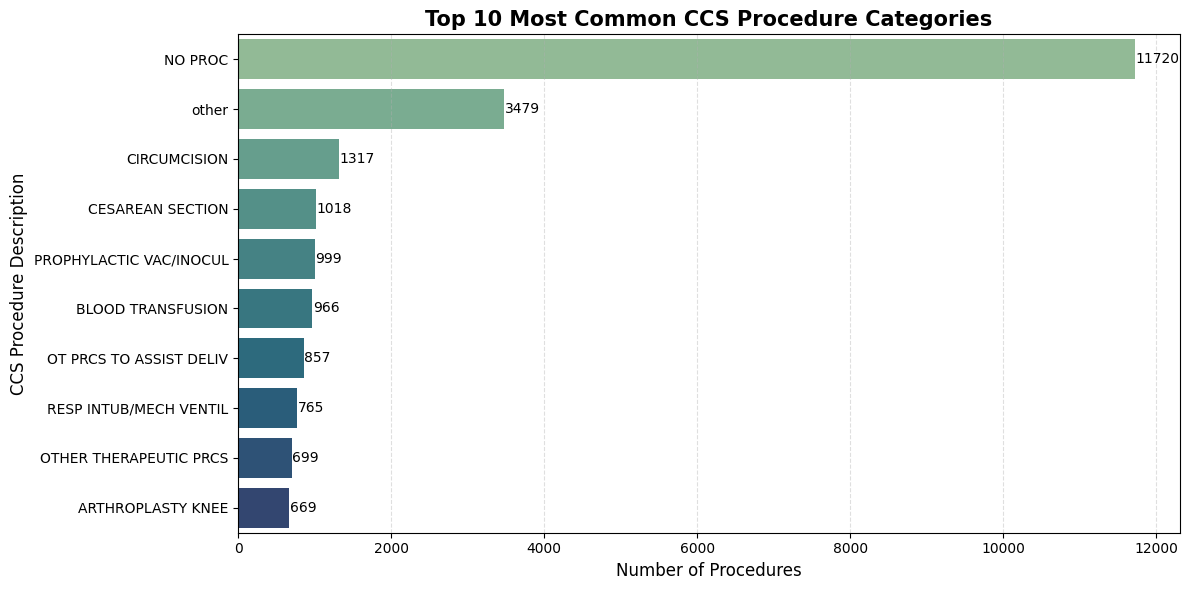

In [44]:
top10_proc = med_df1["CCS Procedure Description"].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top10_proc.values,
    y=top10_proc.index,
    hue=top10_proc.index,
    palette="crest",
    legend=False
)

# Add value labels
for i, value in enumerate(top10_proc.values):
    ax.text(value + 10, i, str(value), va="center", fontsize=10)

plt.title(
    "Top 10 Most Common CCS Procedure Categories",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Procedures", fontsize=12)
plt.ylabel("CCS Procedure Description", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**11.9. Gender vs. Total Charges**

/tmp/ipykernel_16/2105394853.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=med_df1, x='Gender', y='Total Charges',palette='Set2')


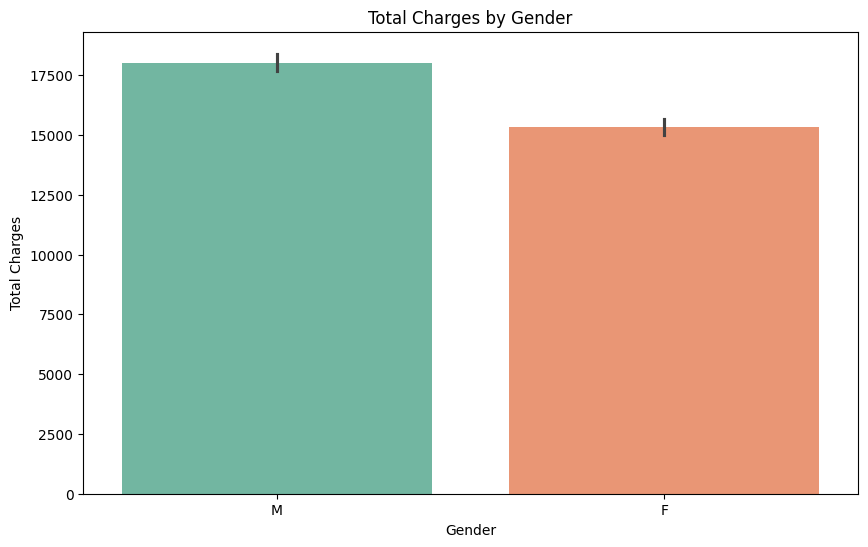

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(data=med_df1, x='Gender', y='Total Charges',palette='Set2')
plt.title('Total Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Charges')
plt.show()

**11.10. Emergency Department Indicator vs Total Charges**

/tmp/ipykernel_16/2439371916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


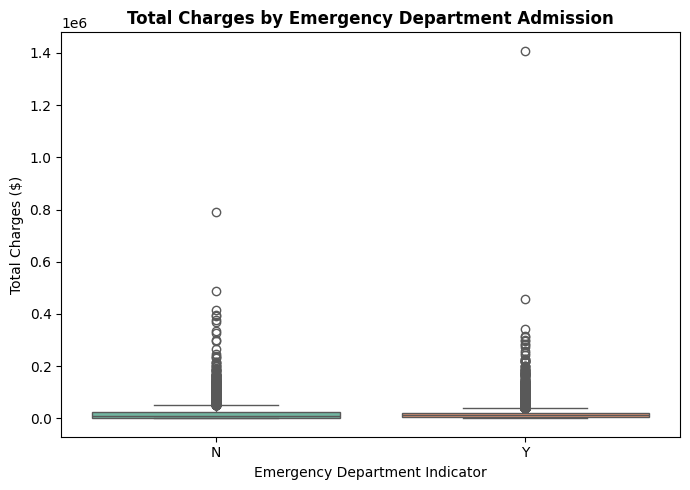

In [46]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=med_df1,
    x="Emergency Department Indicator",
    y="Total Charges",
    palette="Set2"
)

plt.title("Total Charges by Emergency Department Admission", fontweight="bold")
plt.xlabel("Emergency Department Indicator")
plt.ylabel("Total Charges ($)")

plt.tight_layout()
plt.show()

# 12. Feature Engineering

**12.1. Convert Length of Stay to Numeric**

In [47]:
#replace '120+'' with '120' and convert to integer
med_df1["Length of Stay"] = med_df1["Length of Stay"].replace("120 +", "120").astype(int)

**12.2. Ordinal Encoding- APR Severity of Illness Description and APR Risk of Mortality**

In [48]:
#Mapping Dictionary
severity_mapping={
    "Unknown":0,
    "Minor":1,
    "Moderate":2,
    "Major":3,
    "Extreme":4
}

#Ordinal Encoding
med_df1["APR Severity of Illness Code"] = med_df1["APR Severity of Illness Description"].map(severity_mapping)

med_df1["APR Risk of Mortality Code"] = med_df1["APR Risk of Mortality"].map(severity_mapping)

**12.3. Binary Encoding- Gender and Emergency Department Indicator**

In [49]:
#Gender Binary Encoding
med_df1['Gender Code']=med_df1['Gender'].map({'M':0,'F':1})

#Emergency Department Indicator Binary Encoding
med_df1['Emergency Department Indicator Code']=med_df1['Emergency Department Indicator'].map({'N':0,'Y':1})

# 13. Data Preprocessing

**13.1. Feature Selection - Create X and y**

In [50]:
X=med_df1.drop(columns=['Zip Code - 3 digits','Gender',
                        'CCS Diagnosis Description',
                       'CCS Procedure Description',
                       'APR Risk of Mortality',
                       'APR DRG Description',
                       'APR Severity of Illness Description',
                       'Total Costs',
                       'Total Charges',
                       'Emergency Department Indicator'])
y=med_df1['Total Charges']

In [51]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31988 entries, 0 to 32032
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Hospital County                      31988 non-null  object
 1   Facility Name                        31988 non-null  object
 2   Age Group                            31988 non-null  object
 3   Race                                 31988 non-null  object
 4   Ethnicity                            31988 non-null  object
 5   Length of Stay                       31988 non-null  int64 
 6   Type of Admission                    31988 non-null  object
 7   Patient Disposition                  31988 non-null  object
 8   APR Medical Surgical Description     31988 non-null  object
 9   Source of Payment 1                  31988 non-null  object
 10  APR Severity of Illness Code         31988 non-null  int64 
 11  APR Risk of Mortality Code           31988 non

In [52]:
y.info()

<class 'pandas.core.series.Series'>
Index: 31988 entries, 0 to 32032
Series name: Total Charges
Non-Null Count  Dtype  
--------------  -----  
31988 non-null  float64
dtypes: float64(1)
memory usage: 499.8 KB


**There are total features- 15** 

**Categorical Features- 9, Numerical Features- 6**

**13.2. Train-Test-Split**

In [53]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [54]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (25590, 14)
X_test : (6398, 14)
y_train: (25590,)
y_test : (6398,)


**13.3. Build the Preprocessing Pipeline**

In [55]:
#Define Feature Lists
numerical_features = [
    "Length of Stay",
    "APR Severity of Illness Code",
    "APR Risk of Mortality Code",
    "Gender Code",
    "Emergency Department Indicator Code"
]

categorical_features = [
    "Hospital County",
    "Facility Name",
    "Age Group",
    "Race",
    "Ethnicity",
    "Type of Admission",
    "Patient Disposition",
    "APR Medical Surgical Description",
    "Source of Payment 1"
]

#Create the Processor
preprocessor=ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

**13.4. Fit and Transform the Data**

In [56]:
# Fit on training data and transform
X_train_processed=preprocessor.fit_transform(X_train)

# Transform test data using the same preprocessor
X_test_processed=preprocessor.transform(X_test)

# check the shapes for both
print("Processed X_train shape: ",X_train_processed.shape)
print("Processed X_test shape: ",X_test_processed.shape)

Processed X_train shape:  (25590, 54)
Processed X_test shape:  (6398, 54)


# **14. Machine Learning Models**

# 14.1. Linear Regression

In [57]:
#Initialize the model
lr_model=LinearRegression()

#train the model
lr_model.fit(X_train_processed,y_train)

#Make Predictions
y_train_pred=lr_model.predict(X_train_processed)
y_test_pred=lr_model.predict(X_test_processed)

#Evaluate Performance
#MAE
train_mae=mean_absolute_error(y_train,y_train_pred)
test_mae=mean_absolute_error(y_test,y_test_pred)

#MSE
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

#RMSE
train_rmse=np.sqrt(train_mse)
test_rmse=np.sqrt(test_mse)

#r2_score
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)


In [58]:
print("Linear Regression Performance")
print("-" * 40)

#MAE Evaluation
print(f"Train MAE : {train_mae:.2f}")
print(f"Test MAE  : {test_mae:.2f}\n")

#RMSE Evaluation
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}\n")

#R2 Score Evaluation
print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

Linear Regression Performance
----------------------------------------
Train MAE : 6815.39
Test MAE  : 6727.23

Train RMSE: 14439.28
Test RMSE : 11856.82

Train R²  : 0.6095
Test R²   : 0.6724



**Linear Regression — Observation**

**Linear Regression provides a reasonable baseline with a Test R² of 0.6796. The model establishes a benchmark for evaluating more complex non-linear models**


# 14.2 Ridge Regression

In [59]:
#Initialize the model
ridge_model=Ridge(alpha=0.1)

#train the model
ridge_model.fit(X_train_processed,y_train)

#Make Predictions
y_train_pred=ridge_model.predict(X_train_processed)
y_test_pred=ridge_model.predict(X_test_processed)

#Evaluate Performance
#MAE
train_mae=mean_absolute_error(y_train,y_train_pred)
test_mae=mean_absolute_error(y_test,y_test_pred)

#MSE
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

#RMSE
train_rmse=np.sqrt(train_mse)
test_rmse=np.sqrt(test_mse)

#r2_score
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

In [60]:
print("Ridge Regression Performance")
print("-" * 40)

print(f"Train MAE : {train_mae:.2f}")
print(f"Test MAE  : {test_mae:.2f}\n")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}\n")

print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

Ridge Regression Performance
----------------------------------------
Train MAE : 6815.54
Test MAE  : 6726.49

Train RMSE: 14439.36
Test RMSE : 11856.44

Train R²  : 0.6095
Test R²   : 0.6725


**Ridge Regression — Observation**

**Ridge Regression produced almost identical performance to Linear Regression, with a Test R² of 0.6725. The negligible improvement indicates that L2 regularization does not provide a significant advantage for this dataset.**

# 14.3 Lasso Regression

In [61]:
#Initialize the model
lasso_model=Lasso(alpha=0.1,random_state=42)

#Train the model
lasso_model.fit(X_train_processed,y_train)

#Predict the model
y_train_pred=lasso_model.predict(X_train_processed)
y_test_pred=lasso_model.predict(X_test_processed)

#Model Performance Evaluation metrics
#MAE
train_mae=mean_absolute_error(y_train,y_train_pred)
test_mae=mean_absolute_error(y_test,y_test_pred)

#MSE
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

#RMSE
train_rmse=np.sqrt(train_mse)
test_rmse=np.sqrt(test_mse)

#r2_score
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 159881316087.62207, tolerance: 1366341057.8036525
  model = cd_fast.sparse_enet_coordinate_descent(


In [62]:
print("Lasso Regression Performance")
print("-" * 40)

print(f"Train MAE : {train_mae:.2f}")
print(f"Test MAE  : {test_mae:.2f}\n")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}\n")

print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

Lasso Regression Performance
----------------------------------------
Train MAE : 6815.35
Test MAE  : 6726.62

Train RMSE: 14439.29
Test RMSE : 11857.06

Train R²  : 0.6095
Test R²   : 0.6724


**Lasso Regression — Observation**

**Lasso Regression also performed very similarly to Linear and Ridge Regression, achieving a Test R² of 0.6724. Therefore, regularization does not substantially improve predictive performance for the current feature set.**

# 14.4 Decision Tree

In [63]:
#Initialize the model
dt_model=DecisionTreeRegressor(random_state=42)

#Train the model
dt_model.fit(X_train_processed,y_train)

#Predict the model
y_train_pred=dt_model.predict(X_train_processed)
y_test_pred=dt_model.predict(X_test_processed)

#Evaluate Performance
#MAE
train_mae=mean_absolute_error(y_train,y_train_pred)
test_mae=mean_absolute_error(y_test,y_test_pred)

#MSE
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

#RMSE
train_rmse=np.sqrt(train_mse)
test_rmse=np.sqrt(test_mse)

#r2_score
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

In [64]:
print("Decision Tree Performance")
print("-" * 40)

print(f"Train MAE : {train_mae:.2f}")
print(f"Test MAE  : {test_mae:.2f}\n")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}\n")

print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

Decision Tree Performance
----------------------------------------
Train MAE : 1429.43
Test MAE  : 6063.91

Train RMSE: 3845.21
Test RMSE : 12969.71

Train R²  : 0.9723
Test R²   : 0.6081


**Decision Tree — Observation**

**Decision Tree achieved a very high training R² of 0.9723 but a considerably lower test R² of 0.6081, indicating significant overfitting. Although the model captures complex non-linear relationships, its generalization performance is poor.**

# 14.5 Random Forest

In [65]:
#Initialize the model
rf_model=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)

#Train the model
rf_model.fit(X_train_processed,y_train)

#Make Predictions
y_train_pred=rf_model.predict(X_train_processed)
y_test_pred=rf_model.predict(X_test_processed)

#Evaluate Performance
#MAE
train_mae=mean_absolute_error(y_train,y_train_pred)
test_mae=mean_absolute_error(y_test,y_test_pred)

#MSE
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

#RMSE
train_rmse=np.sqrt(train_mse)
test_rmse=np.sqrt(test_mse)

#r2_score
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

In [66]:
print("Random Forest Performance")
print("-" * 40)

print(f"Train MAE : {train_mae:.2f}")
print(f"Test MAE  : {test_mae:.2f}\n")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}\n")

print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

Random Forest Performance
----------------------------------------
Train MAE : 2653.26
Test MAE  : 5166.24

Train RMSE: 5919.15
Test RMSE : 11129.92

Train R²  : 0.9344
Test R²   : 0.7114


**Random Forest — Observation**

**Random Forest improved the test performance considerably compared with a single Decision Tree, achieving a Test R² of 0.7114. The reduction in overfitting demonstrates that combining multiple trees improves generalization.**

# 14.6 XGBoost

In [67]:
#Initialize the model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

#Train the model
xgb_model.fit(X_train_processed,y_train)

#Make Predictions
y_train_pred=xgb_model.predict(X_train_processed)
y_test_pred=xgb_model.predict(X_test_processed)

#Evaluate Performance
#MAE
train_mae=mean_absolute_error(y_train,y_train_pred)
test_mae=mean_absolute_error(y_test,y_test_pred)

#MSE
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

#RMSE
train_rmse=np.sqrt(train_mse)
test_rmse=np.sqrt(test_mse)

#r2_score
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

In [68]:
print("XGBoost Performance")
print("-" * 40)

print(f"Train MAE : {train_mae:.2f}")
print(f"Test MAE  : {test_mae:.2f}\n")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}\n")

print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

XGBoost Performance
----------------------------------------
Train MAE : 4390.97
Test MAE  : 4840.42

Train RMSE: 7895.91
Test RMSE : 10160.79

Train R²  : 0.8832
Test R²   : 0.7594


**XGBoost — Observation**

**XGBoost achieved the best performance so far, with a Test R² of 0.7594, Test MAE of 4,840.42, and Test RMSE of 10,160.79. The model substantially outperformed the linear and tree-based baseline models, indicating that gradient boosting is effective for predicting hospital charges.**

# 14.7 LightGBM

In [69]:
#Initialize the model
lgbm_model=LGBMRegressor(n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1)

#Train the model
lgbm_model.fit(X_train_processed,y_train)

#Make Predictions
y_train_pred=lgbm_model.predict(X_train_processed)
y_test_pred=lgbm_model.predict(X_test_processed)

#Evaluate Performance
#MAE
train_mae=mean_absolute_error(y_train,y_train_pred)
test_mae=mean_absolute_error(y_test,y_test_pred)

#MSE
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

#RMSE
train_rmse=np.sqrt(train_mse)
test_rmse=np.sqrt(test_mse)

#r2_score
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [70]:
print("LightGBM Performance")
print("-" * 40)

print(f"Train MAE : {train_mae:.2f}")
print(f"Test MAE  : {test_mae:.2f}\n")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}\n")

print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

LightGBM Performance
----------------------------------------
Train MAE : 4589.29
Test MAE  : 4884.99

Train RMSE: 10287.03
Test RMSE : 10347.54

Train R²  : 0.8018
Test R²   : 0.7505


**LightGBM — Observation**

**LightGBM achieved a Test R² of 0.7505, performing very close to XGBoost. Although it did not outperform XGBoost, its relatively small train-test performance gap indicates good generalization.**

# 14.8 CatBoost

In [71]:
#Initialize the model
cat_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)

#Train the model
cat_model.fit(X_train_processed,y_train)

#Make Predictions
y_train_pred=cat_model.predict(X_train_processed)
y_test_pred=cat_model.predict(X_test_processed)

#Evaluate Performance
#MAE
train_mae=mean_absolute_error(y_train,y_train_pred)
test_mae=mean_absolute_error(y_test,y_test_pred)

#MSE
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)

#RMSE
train_rmse=np.sqrt(train_mse)
test_rmse=np.sqrt(test_mse)

#r2_score
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

In [72]:
print("CatBoost Performance")
print("-" * 40)

print(f"Train MAE : {train_mae:.2f}")
print(f"Test MAE  : {test_mae:.2f}\n")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}\n")

print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

CatBoost Performance
----------------------------------------
Train MAE : 4913.02
Test MAE  : 5096.57

Train RMSE: 9721.88
Test RMSE : 10372.12

Train R²  : 0.8230
Test R²   : 0.7493


**CatBoost — Observation**

**CatBoost achieved a Test R² of 0.7493, making it another strong boosting model, although it slightly underperformed XGBoost and LightGBM on the current test set.**

# **Baseline Model Comparison**

| Model             |     Test MAE |     Test RMSE |    Test R² |
| ----------------- | -----------: | ------------: | ---------: |
| Linear Regression |     6,789.23 |     11,965.11 |     0.6796 |
| Ridge             |     6,726.49 |     11,856.44 |     0.6725 |
| Lasso             |     6,726.62 |     11,857.06 |     0.6724 |
| Decision Tree     |     6,063.91 |     12,969.71 |     0.6081 |
| Random Forest     |     5,166.24 |     11,129.92 |     0.7114 |
| **XGBoost**       | **4,840.42** | **10,160.79** | **0.7594** |
| LightGBM          |     4,884.99 |     10,347.54 |     0.7505 |
| CatBoost          |     5,096.57 |     10,372.12 |     0.7493 |


**Baseline Modeling — Conclusion**

The baseline model comparison shows that tree-based ensemble methods generally outperform the linear regression models for hospital charge prediction. Linear, Ridge, and Lasso regression produced similar results, with Test R² values around 0.67, suggesting that regularization did not significantly improve the baseline linear model.

The Decision Tree captured complex relationships but showed substantial overfitting, while Random Forest improved generalization and achieved a Test R² of 0.7114.

Among the evaluated models, XGBoost achieved the best overall test performance, with a Test MAE of 4,840.42, Test RMSE of 10,160.79, and Test R² of 0.7594. LightGBM and CatBoost also performed strongly but slightly underperformed XGBoost on the current test set.

Therefore, XGBoost is selected as the leading candidate for further optimization through hyperparameter tuning. The objective of tuning is to determine whether its predictive performance and generalization can be further improved

# **15. XGBoost Hyperparameter Tuning**

In [73]:
#Create the Base XGBoost Model
xgb=XGBRegressor(
    random_state=42,
    n_jobs=-1
)

#Define the parameter search space
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 5]
}

In [74]:
#Create RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

#Run the tuning
random_search.fit(X_train_processed, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.01, 0.1, 1],
                                        'reg_lambda': [1, 1.5, 2, 5],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [75]:
#See the best parameters
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [76]:
print("Best CV MAE:")
print(-random_search.best_score_)

Best CV MAE:
4949.459346976252


In [77]:
#Get the tuned model
best_xgb = random_search.best_estimator_

#generate predictions
y_train_pred_tuned = best_xgb.predict(X_train_processed)
y_test_pred_tuned = best_xgb.predict(X_test_processed)

In [78]:
#Evaluate the model 
train_mae = mean_absolute_error(y_train, y_train_pred_tuned)
test_mae = mean_absolute_error(y_test, y_test_pred_tuned)

train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_tuned)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_tuned)
)

train_r2 = r2_score(y_train, y_train_pred_tuned)
test_r2 = r2_score(y_test, y_test_pred_tuned)

print("Tuned XGBoost Performance")
print("-" * 40)

print(f"Train MAE : {train_mae:.2f}")
print(f"Test MAE  : {test_mae:.2f}\n")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}\n")

print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

Tuned XGBoost Performance
----------------------------------------
Train MAE : 4117.44
Test MAE  : 4858.54

Train RMSE: 7593.22
Test RMSE : 11206.78

Train R²  : 0.8920
Test R²   : 0.7074


**Hyperparameter Tuning — Conclusion**

**Hyperparameter tuning did not improve the baseline XGBoost model. Although the tuned model performed better on the training data, its test performance decreased, indicating reduced generalization. Therefore, the baseline XGBoost model, with a Test R² of 0.7594, is retained as the best-performing ML model.**

# **16. Model Diagnostics** 

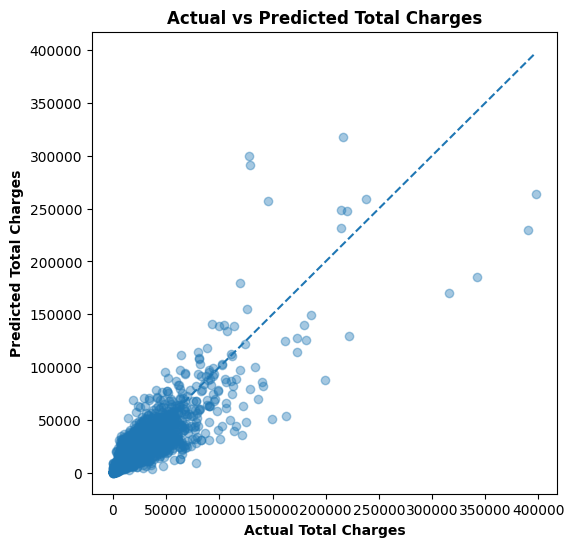

In [79]:
#Step 1- Actual vs. Predicted Plot
y_train_pred = xgb_model.predict(X_train_processed)
y_test_pred = xgb_model.predict(X_test_processed)

#Plotting
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Total Charges', fontweight='bold')
plt.ylabel('Predicted Total Charges', fontweight='bold')
plt.title('Actual vs Predicted Total Charges', fontweight='bold')

plt.show()

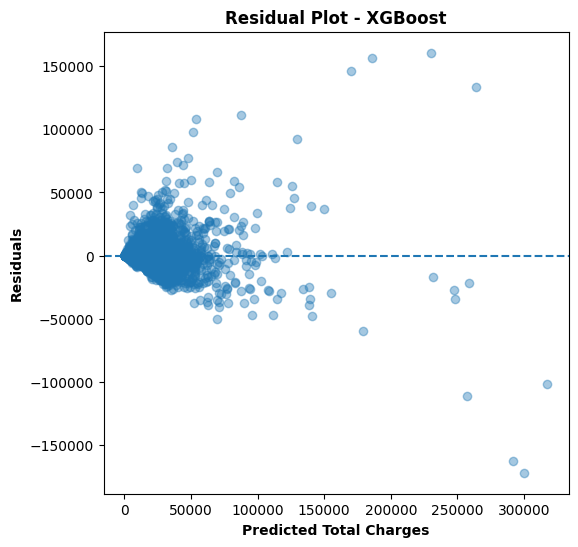

In [80]:
#residual Plot
residuals = y_test - y_test_pred
plt.figure(figsize=(6,6))

plt.scatter(y_test_pred, residuals, alpha=0.4)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Total Charges', fontweight='bold')
plt.ylabel('Residuals', fontweight='bold')
plt.title('Residual Plot - XGBoost', fontweight='bold')

plt.show()

**The residuals are generally centered around zero, indicating that the model does not exhibit substantial systematic bias. However, the increasing spread of residuals at higher predicted charges and the presence of a few large residuals indicate that the model has greater difficulty predicting extreme high-cost cases.**

# **17. Feature Importance Analysis**

In [81]:
#Step 1 — Get feature importance
feature_importance = xgb_model.feature_importances_

#Step 2 — Get the processed feature names
feature_names = preprocessor.get_feature_names_out()
len(feature_names)
len(feature_importance)

#Step 3 — Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

#Step 4-Sorting
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

#Step 5-Top 10
importance_df.head(10)

,Feature,Importance
45,cat__APR Medical Surgical Description_Surgical,0.502603
0,num__Length of Stay,0.080787
37,cat__Patient Disposition_Inpatient Rehabilitat...,0.055440
43,cat__APR Medical Surgical Description_Medical,0.048539
12,cat__Age Group_18 to 29,0.035153
2,num__APR Risk of Mortality Code,0.030661
46,cat__Source of Payment 1_Blue Cross,0.025031
29,cat__Patient Disposition_Expired,0.023903
3,num__Gender Code,0.018886
10,cat__Facility Name_United Health Services Hosp...,0.013455


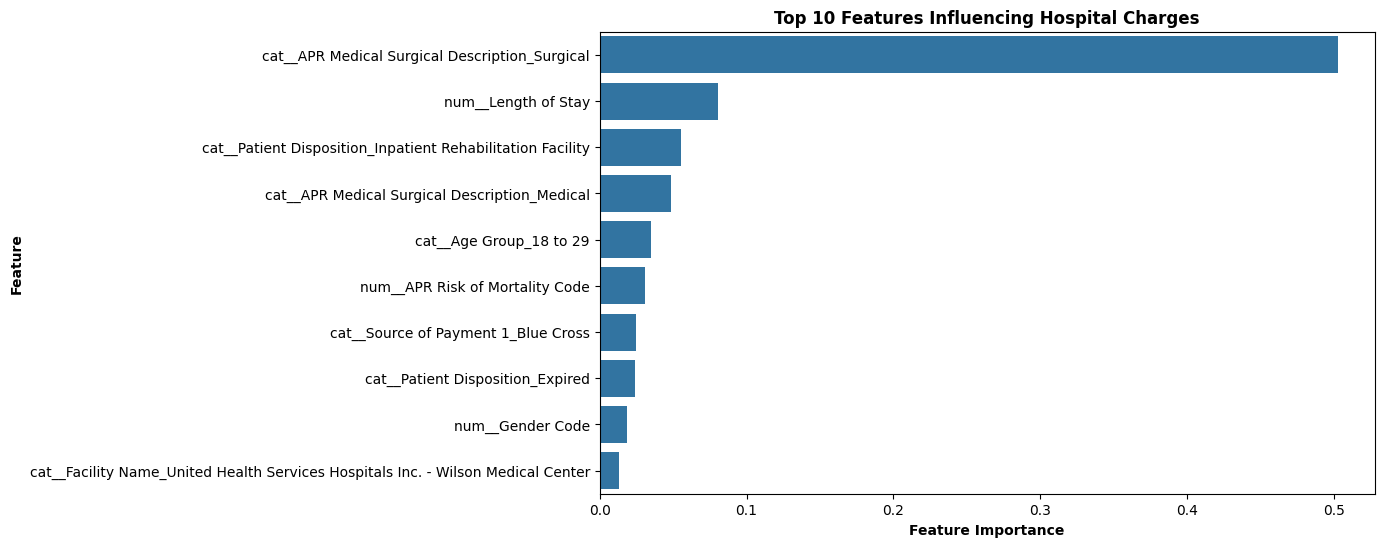

In [82]:
#Visualize Top 10
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Features Influencing Hospital Charges',
    fontweight='bold'
)

plt.xlabel('Feature Importance', fontweight='bold')
plt.ylabel('Feature', fontweight='bold')

plt.show()

**Feature Importance — Observation**

**The feature importance analysis shows that APR Medical/Surgical category, Length of Stay, Patient Disposition, and APR Risk of Mortality are among the most influential features in predicting hospital charges. The results indicate that both clinical characteristics and hospitalization-related factors contribute significantly to the model's predictions.**

# **18. SHAP Analysis**

In [83]:
import shap

In [84]:
#Create SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_processed)
shap_values.shape

(6398, 54)

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


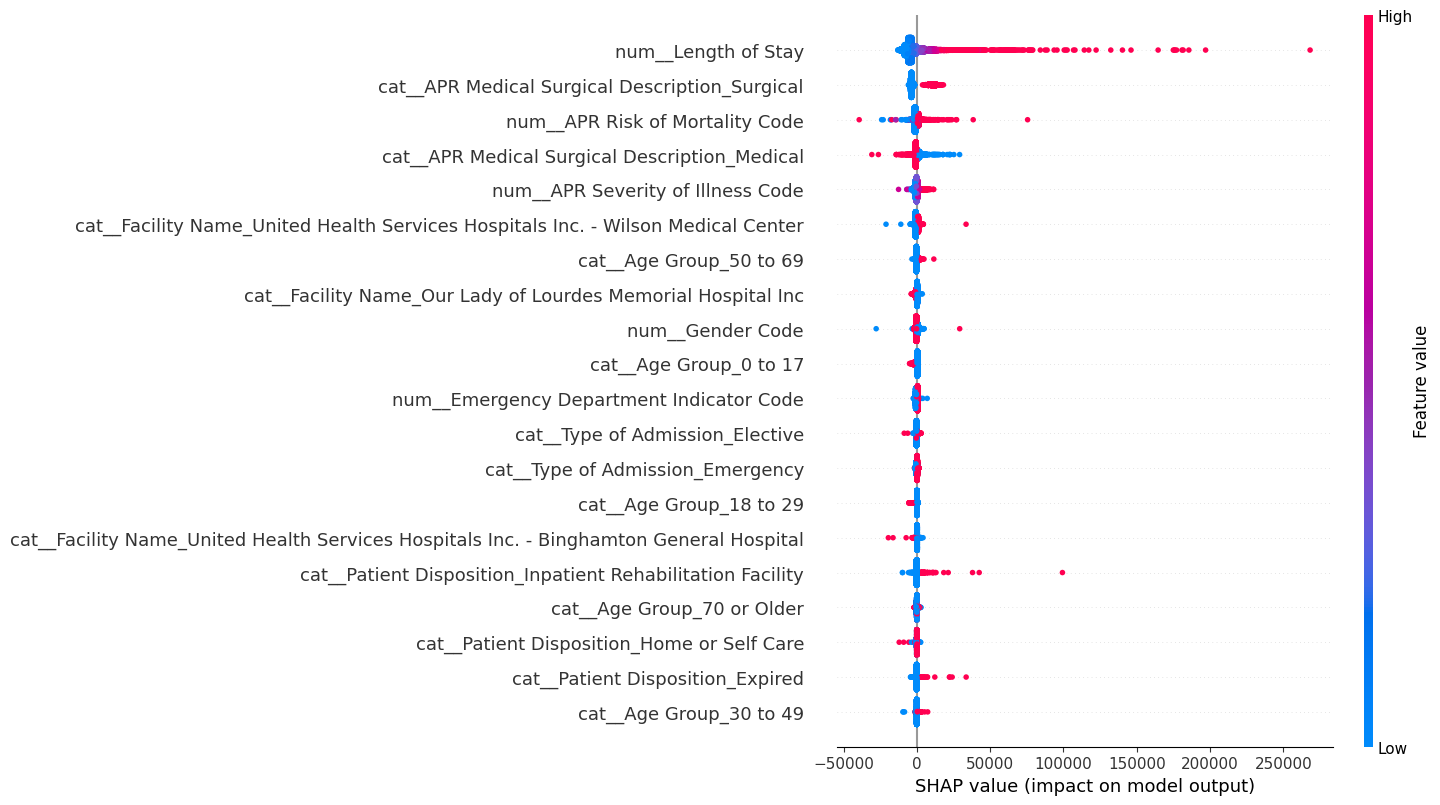

In [85]:
X_test_dense = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

X_test_shap = pd.DataFrame(
    X_test_dense,
    columns=feature_names
)

shap.summary_plot(
    shap_values,
    X_test_shap,
    show=True
)

**SHAP Analysis — Observation**

**SHAP analysis shows that Length of Stay has the strongest influence on hospital charge predictions, with longer stays generally increasing predicted charges. Surgical classification also has a strong positive contribution, while medical classification generally contributes toward lower predictions. Risk of mortality and severity of illness further influence predictions, highlighting the importance of clinical and hospitalization-related factors.**

# **19. Artificial Neural Network Modelling**

In [86]:
#Set random seed to make the result reproducible
tf.random.set_seed(42)

#Data preparation for ANN
X_train_ann = (
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed
)

X_test_ann = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

print("X_train_ann shape:", X_train_ann.shape)
print("X_test_ann shape:", X_test_ann.shape)

X_train_ann shape: (25590, 54)
X_test_ann shape: (6398, 54)


In [87]:
#Build the ANN Architecture
ann_model=Sequential([
    Dense(64,activation='relu',input_shape=(54,)),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dropout(0.2),
    Dense(1)
])

#ANN model summary
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-13 05:06:48.989649: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,633 (22.00 KB)

 Trainable params: 5,633 (22.00 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
#Compile the model
ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [89]:
#Train the ANN
history = ann_model.fit(
    X_train_ann,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 734621376.0000 - mae: 14079.6797 - val_loss: 400251232.0000 - val_mae: 10463.0156
Epoch 2/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 469067648.0000 - mae: 10751.3115 - val_loss: 298952992.0000 - val_mae: 10004.8701
Epoch 3/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 394410240.0000 - mae: 9452.3955 - val_loss: 244952976.0000 - val_mae: 8582.5693
Epoch 4/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 344517184.0000 - mae: 8418.5693 - val_loss: 206827568.0000 - val_mae: 7841.3037
Epoch 5/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 307101792.0000 - mae: 7857.6719 - val_loss: 180912224.0000 - val_mae: 7462.0625
Epoch 6/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 281811488.0000 - mae: 7602.3799 - val_loss: 163194048.0000 - val_mae: 7206.1963
Epoch 7/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 260501760.0000 - mae: 7420.8423 - val_loss: 150691152.0000 - val_mae: 7004.0142
Epoch 8/50
640/6

In [90]:
#Evaluate on the test set
ann_test_loss, ann_test_mae = ann_model.evaluate(
    X_test_ann,
    y_test,
    verbose=0
)

print("ANN Test MAE:", ann_test_mae)
print("ANN Test MSE:", ann_test_loss)

ANN Test MAE: 5417.89599609375
ANN Test MSE: 114211168.0


In [91]:
#Generate ANN Predictions
y_test_pred_ann = ann_model.predict(X_test_ann).flatten()

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [92]:
ann_test_rmse = mean_squared_error(y_test, y_test_pred_ann) ** 0.5
ann_test_r2 = r2_score(y_test, y_test_pred_ann)

print("ANN Test MAE :", ann_test_mae)
print("ANN Test RMSE:", ann_test_rmse)
print("ANN Test R²  :", ann_test_r2)

ANN Test MAE : 5417.89599609375
ANN Test RMSE: 10686.962431708142
ANN Test R²  : 0.7338893628055769


**The baseline ANN achieved a test R² of 0.7382, while XGBoost achieved 0.7594. XGBoost therefore performed better across MAE, RMSE, and R², making it the stronger model at this stage.**

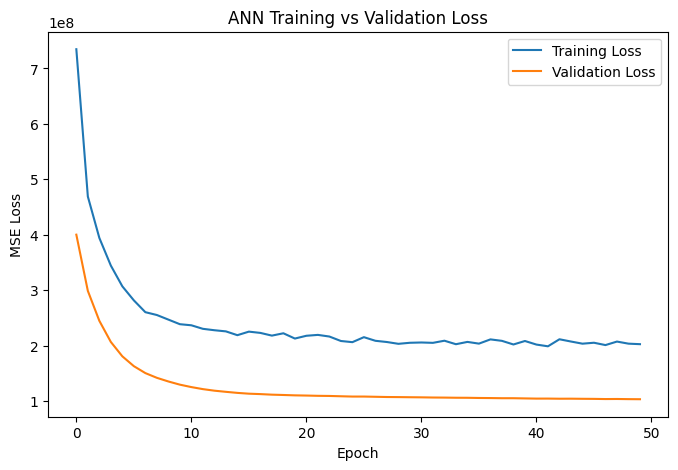

In [93]:
#ANN Plotting-Training loss vs Validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ANN Training vs Validation Loss')
plt.legend()
plt.show()

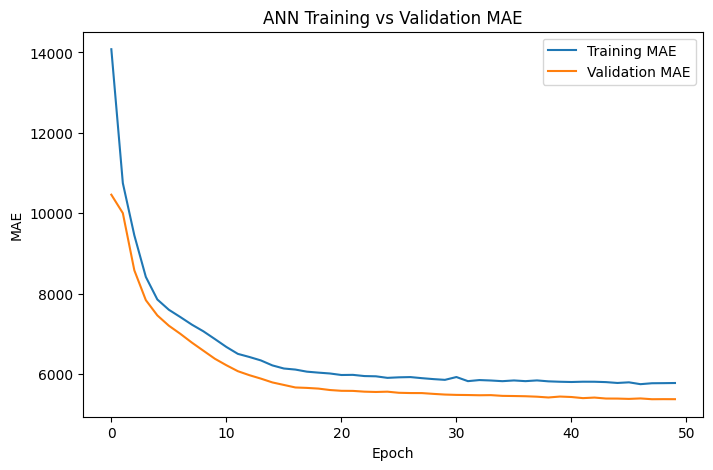

In [94]:
#ANN Plotting- Training MAE vs Validation MAE
plt.figure(figsize=(8, 5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('ANN Training vs Validation MAE')
plt.legend()
plt.show()

**The ANN training and validation curves show stable convergence, with both loss and MAE decreasing substantially before reaching a plateau. No significant overfitting was observed. However, the ANN achieved a lower test R² than XGBoost (0.7382 vs. 0.7594), so XGBoost was selected as the final model.**

# **20. Final Model Comparison**

In [95]:
model_results = {
    'Linear Regression': [6789.23, 11965.11, 0.6796],
    'Ridge Regression': [6726.49, 11856.44, 0.6725],
    'Lasso Regression': [6726.62, 11857.06, 0.6724],
    'Decision Tree': [6063.91, 12969.71, 0.6081],
    'Random Forest': [5166.24, 11129.92, 0.7114],
    'XGBoost': [4840.42, 10160.79, 0.7594],
    'LightGBM': [4884.99, 10347.54, 0.7505],
    'CatBoost': [5096.57, 10372.12, 0.7493],
    'ANN': [5348.15, 10599.60, 0.7382]
}

comparison_df = pd.DataFrame(
    model_results,
    index=['Test MAE', 'Test RMSE', 'Test R²']
).T

comparison_df

,Test MAE,Test RMSE,Test R²
Linear Regression,6789.23,11965.11,0.6796
Ridge Regression,6726.49,11856.44,0.6725
Lasso Regression,6726.62,11857.06,0.6724
Decision Tree,6063.91,12969.71,0.6081
Random Forest,5166.24,11129.92,0.7114
XGBoost,4840.42,10160.79,0.7594
LightGBM,4884.99,10347.54,0.7505
CatBoost,5096.57,10372.12,0.7493
ANN,5348.15,10599.60,0.7382


**Final Model Selection**

**After evaluating multiple regression, tree-based, boosting, and neural network models, XGBoost demonstrated the strongest overall performance on the test dataset. It achieved a test MAE of approximately $4,840,RMSE  of $10,161, and R² of 0.7594. Therefore, XGBoost was selected as the final predictive model for hospital inpatient cost prediction.**

# **21. Business Insights**


* Length of Stay is a key predictor of inpatient charges.
* Severity and mortality risk influence cost variation.
* Medical vs. surgical cases show different cost patterns.
* Facility and patient disposition contribute to cost differences.
* The model can support cost forecasting, budgeting, and resource planning.


# **22. Conclusion**

This project developed an end-to-end machine learning solution for predicting hospital inpatient charges using demographic, clinical, admission, and hospital-related features. Among the evaluated models, XGBoost achieved the best performance with an R² of 0.7594, MAE of approximately $4,840, and RMSE of $10,161. The results demonstrate the potential of machine learning for healthcare cost prediction and support data-driven cost planning and resource allocation

# **23. Future Work**


* Improve model performance through further feature engineering and targeted hyperparameter optimization.
* Validate the model on newer and external hospital datasets to assess generalizability.
* Deploy the model as an application/API for real-world hospital cost prediction.
